## Importaciones

In [1]:
import gdsfactory as gf

In [2]:
from upvfab.sin300.cband import PDK, cells  # celdas --> componentes
                                            # PDK --> materiales, distancias seguras, layers

### Parámetros importantes

Primero es necesario definir los parámetros que son importantes para el layout, como lo son las longitudes que se usarán más adelante, las secciones transversales, entre otras.  

In [3]:
nm=1e-3

# Parametros de DC para cada acople:
gap_selected=0.35
Length_DC=[43.464+0.15, 23.519+0.28, 27.68+0.25,  12.48+0.27,  32.077+0.6] # aqui vemos como ya se tienen en cuenta
                                                                            # las longitudes optimizadas


# Parametros de los MZI
L_1=20
L_2_40=5.937
L_2_80=12.968

L_pi_select=0.3287

#Parámetros de seguridad
DistMinAcople=1 # distancia hallada para que no haya crosstalk

# Longitud de los tapper para las guias gruesas:
L_tapper=0.5

# Longitudes para los gráficos
L_bend=10.5+L_tapper 
L_entre_puertosDC=3.55 # Longitud entre las guias de entrada/salida del acoplador direccional

#Parámetros para el DIE
layer_wg = "WG"
layer_box = "FLOORPLAN"
dieW = 5000
border=250


#Longitud de las guias
width=450*nm # narrow
width2=650*nm # wide



# Secciones transversales
xs = gf.cross_section.strip(width=width, layer = 'WG')
xs_2 = gf.cross_section.strip(width=width2, layer = 'WG')

#bend=gf.components.bend_euler(cross_section=xs)



### Definición de funciones

#### Función para el DIE

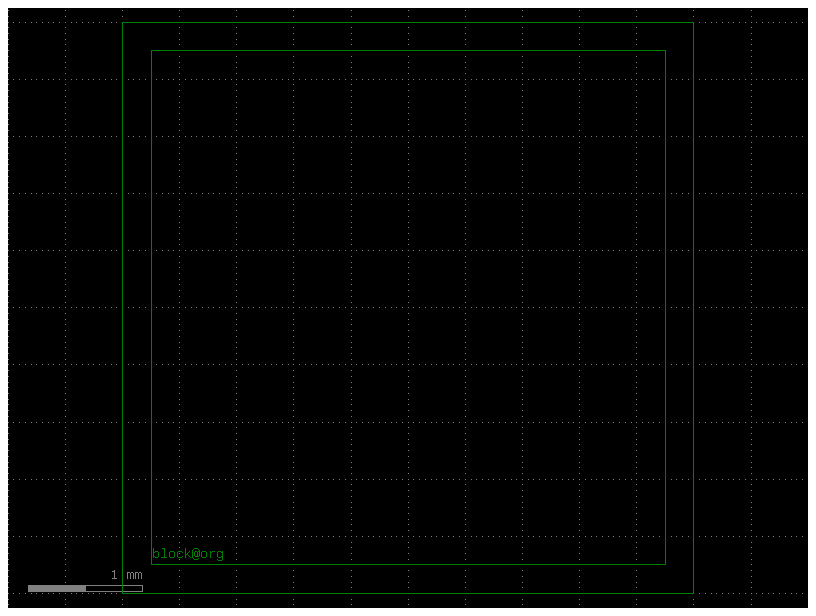

In [4]:

gf.clear_cache()

@gf.cell  # importante ponerle esto, para decirle que es una celfa de gdsfactory
def die(dieL = 5000, dieW = 5000, border = 250, layer_box = "FLOORPLAN"):

    box = gf.Component()
    obox = box.add_ref(gf.components.rectangle(size=(dieW,dieL),layer=layer_box))
    ibox = box.add_ref(gf.components.rectangle(size=(dieW-border*2,dieL-border*2),layer=layer_box)).dmovex(border).dmovey(border)
    box = gf.boolean(A=obox, B=ibox, operation="A-B", layer=layer_box)

    box.add_port(name="block@org", center=[border,border], width=1, orientation=0, layer=layer_box)
    box.draw_ports()
    return box

wafer = gf.Component()
c1 = wafer.add_ref(die(dieW = dieW))

wafer.plot()


#### Función para cada brazo. 

Es necesario dibujar cada brazo del MZI teniendo en cuenta que dentro de las diferencias de caminos puede que se tenga que hacer uso de un tapper para poder poner la guia ancha.

2026-05-24 11:53:12.411 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


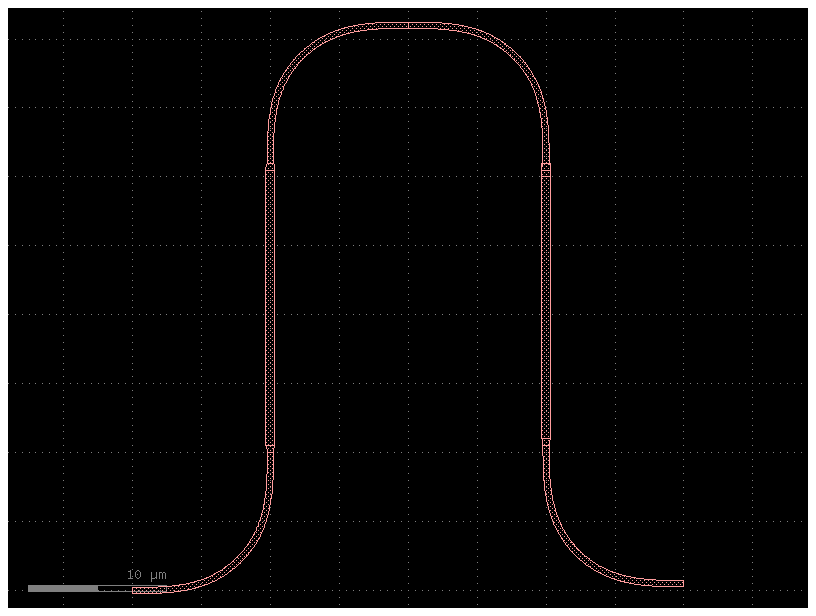

In [5]:

gf.clear_cache()
@gf.cell  
def caminos(L_wg=L_1,cross_section=xs_2,width_out=width2):
    
    #componentes
    caminos = gf.Component()
    wvg_n=gf.components.straight(length=L_wg, cross_section=cross_section)
    taper_in = gf.components.taper(length=0.5, width1=0.45, width2=width_out, layer=layer_wg)
    taper_out = gf.components.taper(length=0.5, width1=width_out, width2=0.45, layer=layer_wg)
    bend=gf.components.bend_euler(cross_section=xs)

    
    # anado los componentes 
    _wg_n=caminos.add_ref(wvg_n)
    _bend1=caminos.add_ref(bend)
    _bend2=caminos.add_ref(bend)
    _bend3=caminos.add_ref(bend)
    _wg_n2=caminos.add_ref(wvg_n)
    _bend4=caminos.add_ref(bend)

    _taper1=caminos.add_ref(taper_in)
    _taper2=caminos.add_ref(taper_out)
    _taper3=caminos.add_ref(taper_in)
    _taper4=caminos.add_ref(taper_out)

    # Muevo los componentes al lugar donde los quiero poner

    _taper1.rotate(90).dmovex(_bend1['o2'].dx).dmovey(_bend1['o2'].dy)
    _wg_n.rotate(90).dmovex(_taper1['o2'].dx).dmovey(_taper1['o2'].dy)
    _taper2.rotate(90).dmovex(_wg_n['o2'].dx).dmovey(_wg_n['o2'].dy)
    _bend2.rotate(180).dmovex(_taper2['o2'].dx-_bend2['o2'].dx).dmovey(_taper2['o2'].dy-_bend2['o2'].dy)
    _bend3.rotate(90).dmovex(_bend2['o2'].dx-2*_bend3['o2'].dx).dmovey(_bend2['o2'].dy)
    _taper3.rotate(-90).dmovex(_bend3['o1'].dx).dmovey(_bend3['o1'].dy)
    _wg_n2.rotate(270).dmovex(_taper3['o1'].dx).dmovey(_taper3['o1'].dy)
    _taper4.rotate(-90).dmovex(_wg_n2['o2'].dx).dmovey(_wg_n2['o2'].dy)
    _bend4.rotate(270).dmovex(_taper4['o2'].dx).dmovey(_taper4['o2'].dy)


    # dependiendo de si la guia es ancha o no debo seleccionar una seccion transversal para conectarla
    if width_out==0.65:
        xs_sbend=xs_2
    else:
        xs_sbend=xs
        
    # se hacen las conecciones
    gf.routing.route_single_sbend(caminos,port1=_bend1['o2'], port2=_taper1['o1'], cross_section=xs)
    gf.routing.route_single_sbend(caminos,port1=_taper1['o2'], port2=_wg_n['o1'], cross_section=xs_sbend)
    gf.routing.route_single_sbend(caminos,port1=_wg_n['o2'], port2=_taper2['o1'], cross_section=xs_sbend)
    gf.routing.route_single_sbend(caminos,port1=_taper2['o2'], port2=_bend2['o2'], cross_section=xs)
    gf.routing.route_single_sbend(caminos,port1=_bend2['o1'], port2=_bend3['o2'], cross_section=xs)
    gf.routing.route_single_sbend(caminos,port1=_bend3['o1'], port2=_taper3['o1'], cross_section=xs)
    gf.routing.route_single_sbend(caminos,port1=_taper3['o2'], port2=_wg_n2['o1'], cross_section=xs_sbend)
    gf.routing.route_single_sbend(caminos,port1=_wg_n2['o2'], port2=_taper4['o1'], cross_section=xs_sbend)
    gf.routing.route_single_sbend(caminos,port1=_taper4['o2'], port2=_bend4['o1'], cross_section=xs)

    # se anñaden los puertos
    caminos.add_port(name="o1", center=[_bend1['o1'].dx,_bend1['o1'].dy], width=width, orientation=180, layer=layer_wg)
    caminos.add_port(name="o2", center=[_bend4['o2'].dx,_bend4['o2'].dy], width=width, orientation=0, layer=layer_wg)

    return caminos
 
cam = gf.Component()
cx = cam.add_ref(caminos())
cam.show()
cam.plot()

Una vez con el diseño del camino ya sea de arriba o de abajo del MZI, se puede generar una estructura básica que se repite para los bloques S1 y S2. Esta consta de un acoplador direccional al inicio con la función de arriba conectada a las salidas del DC.

2026-05-24 11:53:15.723 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


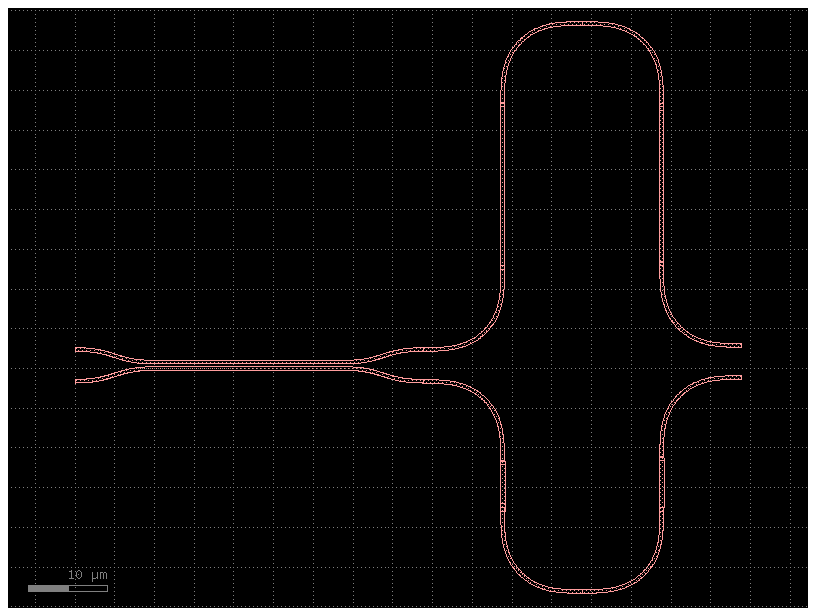

In [6]:

@gf.cell  # importante ponerle esto, para decirle que es una celfa de gdsfactory
def estructura1(cross_section=xs_2,width_out=width2,gap_selected=gap_selected,L_DC=Length_DC[1],L_up=L_1,L_down=L_2_40,cross_section_up=xs,cross_section_down=xs_2,width_out_up=width,width_out_down=width2):
    
    #Componentes
    est1 = gf.Component()
    dc = gf.components.coupler(gap=gap_selected, length=L_DC, cross_section=xs)
    
    # añadimos los componentes 
    _dc=est1.add_ref(dc)
    _caminos=est1.add_ref(caminos(L_wg=L_up,cross_section=cross_section_up,width_out=width_out_up))
    _caminos2=est1.add_ref(caminos(L_wg=L_down,cross_section=cross_section_down,width_out=width_out_down))

    #Los movemos para poder conectarlos despues
    _caminos.dmovex(_dc['o3'].dx).dmovey(_dc['o3'].dy)
    _caminos2.connect('o2',_dc['o4'])

    #Los conectamos
    gf.routing.route_single_sbend(est1,port1=_dc['o3'], port2=_caminos['o1'], cross_section=xs)
    gf.routing.route_single_sbend(est1,port1=_dc['o4'], port2=_caminos2['o2'], cross_section=xs)

    # añadimos los puertos
    est1.add_port(name="o1", center=[_dc['o2'].dx,_dc['o2'].dy], width=width, orientation=180, layer=layer_wg)
    est1.add_port(name="o2", center=[_dc['o1'].dx,_dc['o1'].dy], width=width, orientation=180, layer=layer_wg)
    est1.add_port(name="o3", center=[_caminos['o2'].dx,_caminos['o2'].dy], width=width, orientation=0, layer=layer_wg)
    est1.add_port(name="o4", center=[_caminos2['o1'].dx,_caminos2['o1'].dy], width=width, orientation=0, layer=layer_wg)

    return est1
    

wafer3 = gf.Component()
c3 = wafer3.add_ref(estructura1())
wafer3.show()
wafer3.plot()

Ahora si se hace el diseño del bloque S1 y S2.

2026-05-24 11:53:18.576 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


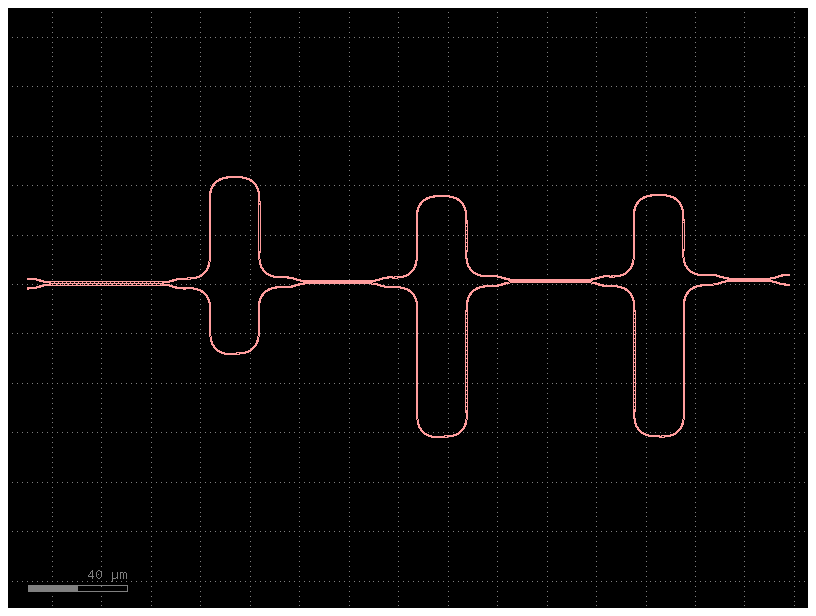

In [7]:
#s1
@gf.cell  # importante ponerle esto, para decirle que es una celfa de gdsfactory
def s1(gap_selected=gap_selected,L_DC=Length_DC,L1=L_1):
    
    #Componentes

    s1 = gf.Component()
    dc = gf.components.coupler(gap=gap_selected, length=L_DC[3], cross_section=xs)
  
    # anadimos los componentes 
    _dc=s1.add_ref(dc)
    _est1_a=s1.add_ref(estructura1(width_out=width2,L_DC=L_DC[0],L_up=L1,L_down=L_2_40,cross_section_up=xs_2,cross_section_down=xs,width_out_up=width2,width_out_down=width))
    _est1_b=s1.add_ref(estructura1(width_out=width2,L_DC=L_DC[1],L_up=2*L_2_40,L_down=2*L1,cross_section_up=xs,cross_section_down=xs_2,width_out_up=width,width_out_down=width2))
    _est1_c=s1.add_ref(estructura1(width_out=width2,L_DC=L_DC[2],L_up=2*L_2_40,L_down=2*L1+L_pi_select,cross_section_up=xs,cross_section_down=xs_2,width_out_up=width,width_out_down=width2))

    # permite que se muevan y se conecten los componentes a uno anterior
    _est1_b.connect('o1', _est1_a['o3'])
    _est1_c.connect('o1', _est1_b['o3'])
    _dc.connect('o2', _est1_c['o3'])
 
    gf.routing.route_single_sbend(s1,port1=_est1_a['o3'], port2=_est1_b['o1'], cross_section=xs)
    gf.routing.route_single_sbend(s1,port1=_est1_a['o4'], port2=_est1_b['o2'], cross_section=xs)
    gf.routing.route_single_sbend(s1,port1=_est1_b['o3'], port2=_est1_c['o1'], cross_section=xs)
    gf.routing.route_single_sbend(s1,port1=_est1_b['o4'], port2=_est1_c['o2'], cross_section=xs)
    gf.routing.route_single_sbend(s1,port1=_est1_c['o3'], port2=_dc['o2'], cross_section=xs)
    gf.routing.route_single_sbend(s1,port1=_est1_c['o4'], port2=_dc['o1'], cross_section=xs)

    # Se añaden los puertos
    s1.add_port(name="i1", center=[_est1_a['o1'].dx,_est1_a['o1'].dy], width=width, orientation=180, layer=layer_wg)
    s1.add_port(name="i0", center=[_est1_a['o2'].dx,_est1_a['o2'].dy], width=width, orientation=180, layer=layer_wg)
    s1.add_port(name="o1", center=[_dc['o3'].dx,_dc['o3'].dy], width=width, orientation=0, layer=layer_wg)
    s1.add_port(name="o0", center=[_dc['o4'].dx,_dc['o4'].dy], width=width, orientation=0, layer=layer_wg)
    
    #s1.draw_ports()
    return s1
    

wafer = gf.Component()
c = wafer.add_ref(s1())
wafer.show()
wafer.plot()

2026-05-24 11:53:21.336 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


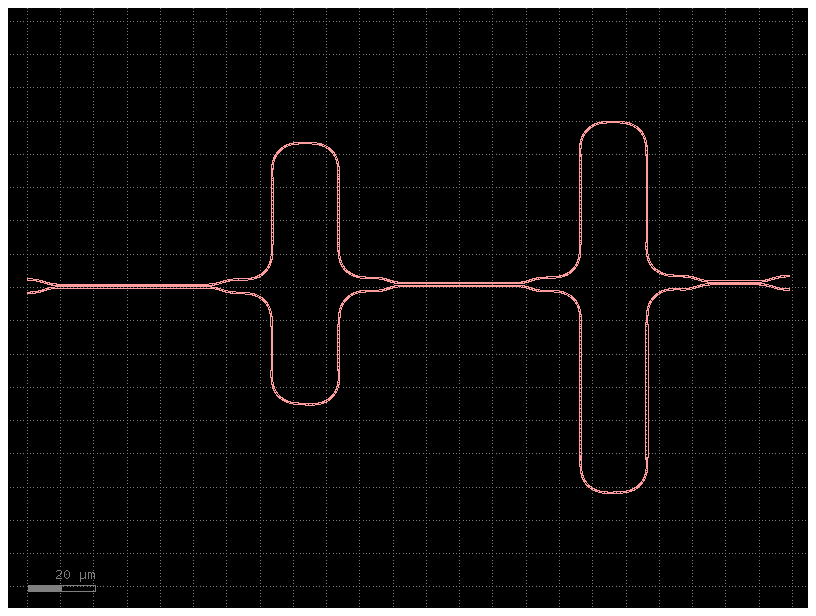

In [8]:
#s2
@gf.cell  # importante ponerle esto, para decirle que es una celfa de gdsfactory
def s2(gap_selected=gap_selected,L_DC=Length_DC,L1=L_1):
    
    #Componentes
    s2 = gf.Component()
    dc = gf.components.coupler(gap=gap_selected, length=L_DC[3], cross_section=xs)
    
    # se añaden los componentes
    _dc=s2.add_ref(dc)
    _est1_a=s2.add_ref(estructura1(width_out=width2,L_DC=L_DC[0],L_up=L1,L_down=L_2_80,cross_section_up=xs_2,cross_section_down=xs,width_out_up=width2,width_out_down=width))
    _est1_b=s2.add_ref(estructura1(width_out=width2,L_DC=L_DC[4],L_up=2*L_2_80,L_down=2*L1,cross_section_up=xs,cross_section_down=xs_2,width_out_up=width,width_out_down=width2))
    
    # se conectan y mueven 
    _est1_b.connect('o1', _est1_a['o3'])
    _dc.connect('o2', _est1_b['o3'])
    
    gf.routing.route_single_sbend(s2,port1=_est1_a['o3'], port2=_est1_b['o1'], cross_section=xs)
    gf.routing.route_single_sbend(s2,port1=_est1_a['o4'], port2=_est1_b['o2'], cross_section=xs)
    gf.routing.route_single_sbend(s2,port1=_est1_b['o3'], port2=_dc['o2'], cross_section=xs)
    gf.routing.route_single_sbend(s2,port1=_est1_b['o4'], port2=_dc['o1'], cross_section=xs)

    # Se añaden los puertos
    s2.add_port(name="i1", center=[_est1_a['o1'].dx,_est1_a['o1'].dy], width=width, orientation=180, layer=layer_wg)
    s2.add_port(name="i0", center=[_est1_a['o2'].dx,_est1_a['o2'].dy], width=width, orientation=180, layer=layer_wg)
    s2.add_port(name="o1", center=[_dc['o3'].dx,_dc['o3'].dy], width=width, orientation=0, layer=layer_wg)
    s2.add_port(name="o0", center=[_dc['o4'].dx,_dc['o4'].dy], width=width, orientation=0, layer=layer_wg)
    
    #s2.draw_ports()
    return s2
    

wafer2 = gf.Component()
c2 = wafer2.add_ref(s2())
wafer2.show()
wafer2.plot()

Para el caso de la variación del bloque S2 solo es necesario cambiar la longitud L1:

2026-05-24 11:53:23.882 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


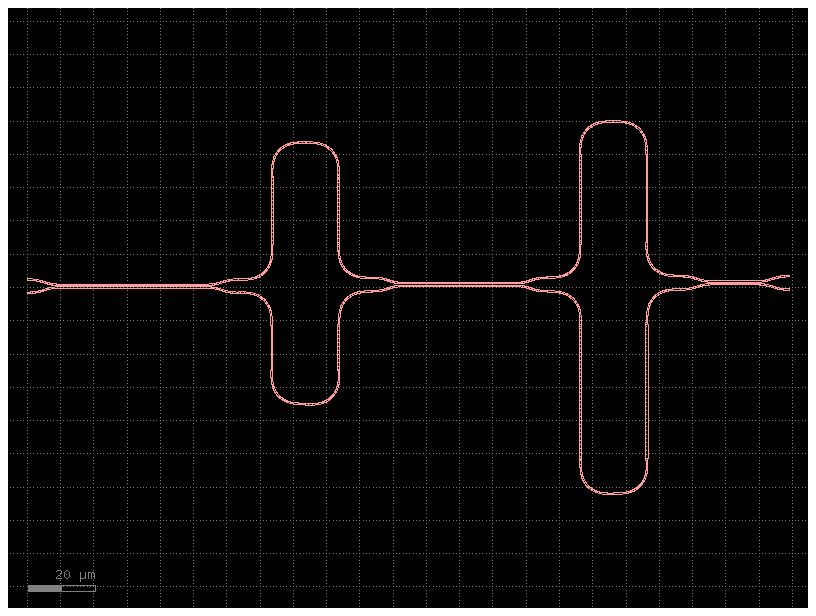

In [9]:
wafer_s22 = gf.Component()
c22 = wafer_s22.add_ref(s2(L1=L_1+0.5*L_pi_select))

wafer_s22.show()
wafer_s22.plot()

Se define por completo la estructura, aqui voy a hacer la conexión 

2026-05-24 11:53:26.637 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


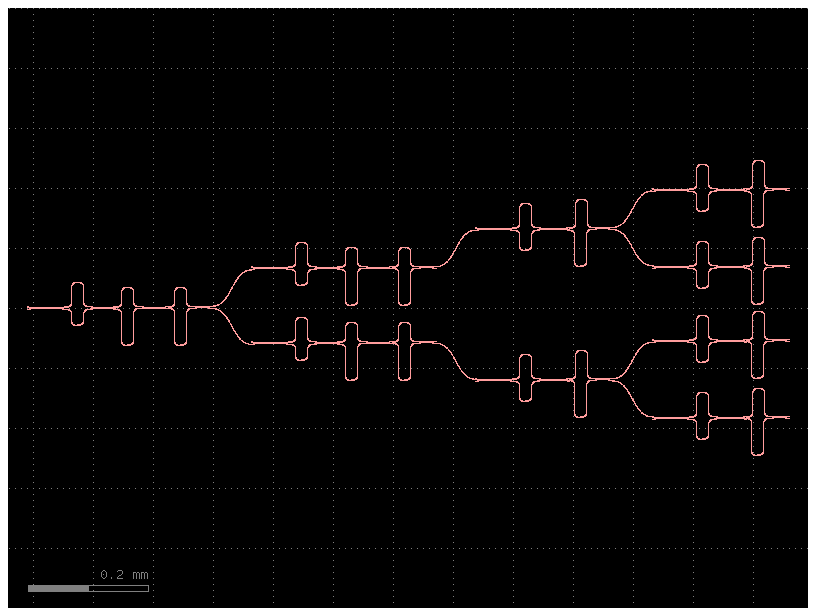

In [10]:

Delta1=2*(L_1+L_bend)
gf.clear_cache()
@gf.cell  # importante ponerle esto, para decirle que es una celfa de gdsfactory
def CWDM(L1=L_1,k=Length_DC):
    
    #Componente
    CWDM = gf.Component()

    # Añadimos los componentes 
    _s1_a=CWDM.add_ref(s1(L_DC=k))
    _s1_b=CWDM.add_ref(s1(L_DC=k))
    _s1_c=CWDM.add_ref(s1(L_DC=k))
    _s2_3=CWDM.add_ref(s2(L_DC=k))
    _s2_3_s3=CWDM.add_ref(s2(L1=L_1+0.5*L_pi_select,L_DC=k))
    _s2_4a=CWDM.add_ref(s2(L_DC=k))
    _s2_4b=CWDM.add_ref(s2(L_DC=k))
    _s2_4_s3a=CWDM.add_ref(s2(L1=L_1+0.5*L_pi_select,L_DC=k))
    _s2_4_s3b=CWDM.add_ref(s2(L1=L_1+0.5*L_pi_select,L_DC=k))

    #Los movemos 
    _s1_b.dmovex(_s1_a['o1'].dx+3*25).dmovey(_s1_a['o1'].dy+Delta1)
    _s1_c.dmovex(_s1_a['o0'].dx+3*25).dmovey(_s1_a['o1'].dy-Delta1)
    
    _s2_3.dmovex(_s1_b['o1'].dx+3*25).dmovey(_s1_b['o1'].dy+Delta1)
    _s2_3_s3.dmovex(_s1_c['o0'].dx+3*25).dmovey(_s1_c['o0'].dy-Delta1)
  
    _s2_4a.dmovex(_s2_3['o1'].dx+3*25).dmovey(_s2_3['o1'].dy+Delta1)
    _s2_4b.dmovex(_s2_3['o0'].dx+3*25).dmovey(_s2_3['o0'].dy-Delta1)
    _s2_4_s3a.dmovex(_s2_3_s3['o1'].dx+3*25).dmovey(_s2_3_s3['o1'].dy+Delta1)
    _s2_4_s3b.dmovex(_s2_3_s3['o0'].dx+3*25).dmovey(_s2_3_s3['o0'].dy-Delta1)

    # Los conectamos
    gf.routing.route_single_sbend(CWDM,port1=_s1_a['o1'], port2=_s1_b['i0'], cross_section=xs)
    gf.routing.route_single_sbend(CWDM,port1=_s1_a['o0'], port2=_s1_c['i0'], cross_section=xs)
    gf.routing.route_single_sbend(CWDM,port1=_s1_b['o1'], port2=_s2_3['i0'], cross_section=xs)
    gf.routing.route_single_sbend(CWDM,port1=_s1_c['o0'], port2=_s2_3_s3['i1'], cross_section=xs)
    gf.routing.route_single_sbend(CWDM,port1=_s2_3['o1'], port2=_s2_4a['i0'], cross_section=xs)
    gf.routing.route_single_sbend(CWDM,port1=_s2_3['o0'], port2=_s2_4b['i1'], cross_section=xs)
    gf.routing.route_single_sbend(CWDM,port1=_s2_3_s3['o1'], port2=_s2_4_s3a['i0'], cross_section=xs)
    gf.routing.route_single_sbend(CWDM,port1=_s2_3_s3['o0'], port2=_s2_4_s3b['i1'], cross_section=xs)

    # Añadimos puertos
    CWDM.add_port(name="i1", center=[_s1_a['i1'].dx,_s1_a['i1'].dy], width=width, orientation=180, layer=layer_wg)
    CWDM.add_port(name="i0", center=[_s1_a['i0'].dx,_s1_a['i0'].dy], width=width, orientation=180, layer=layer_wg)
    CWDM.add_port(name="o3", center=[_s2_4a['o1'].dx,_s2_4a['o1'].dy], width=width, orientation=0, layer=layer_wg)
    CWDM.add_port(name="o2", center=[_s2_4b['o1'].dx,_s2_4b['o1'].dy], width=width, orientation=0, layer=layer_wg)
    CWDM.add_port(name="o1", center=[_s2_4_s3a['o0'].dx,_s2_4_s3a['o0'].dy], width=width, orientation=0, layer=layer_wg)
    CWDM.add_port(name="o0", center=[_s2_4_s3b['o0'].dx,_s2_4_s3b['o0'].dy], width=width, orientation=0, layer=layer_wg)
    
    #CWDM.draw_ports()
    return CWDM
    

wafer_fin = gf.Component()
c_fin = wafer_fin.add_ref(CWDM())

wafer_fin.show()
wafer_fin.plot()

Por último, creamos la estructura del gratting, como nuestra guia es de 450 nm, se le pone un tapper adicional al grating de la libreria. 

2026-05-24 11:53:29.522 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


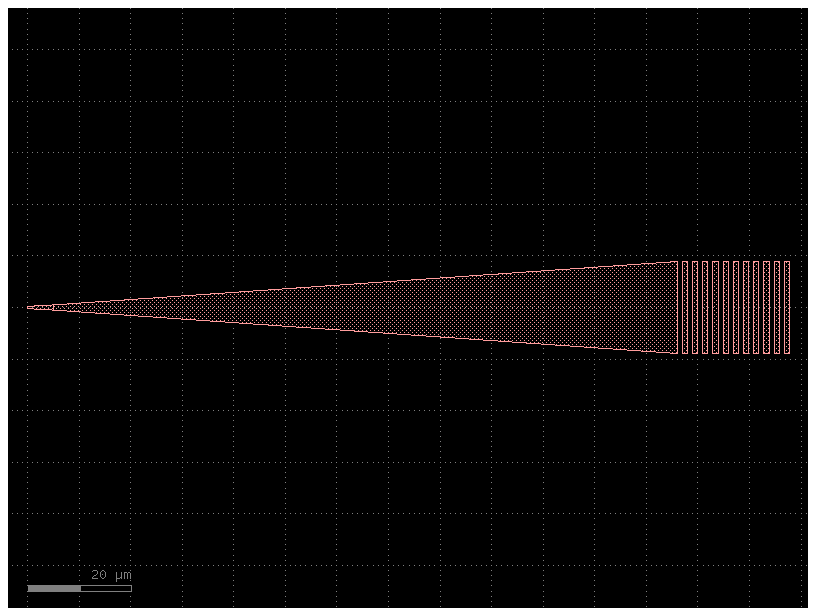

In [11]:
taper_in = gf.components.taper(length=0.5, width1=0.45, width2=1, layer=layer_wg)

gf.clear_cache()
@gf.cell  # importante ponerle esto, para decirle que es una celfa de gdsfactory
def grating():
    
    #Componente
    taper = gf.Component()

    # Añadimos los componentes 
    _grating=taper.add_ref(cells.grating_coupler_rectangular())
    _taper=taper.add_ref(gf.components.taper(length=5, width1=0.45, width2=1, layer=layer_wg))

    #Los movemos y conectamos
    _grating.connect('o1', _taper['o2'])
 
    # Añadimos puertos
    taper.add_port(name="i0", center=[_taper['o1'].dx,_taper['o1'].dy], width=width, orientation=180, layer=layer_wg)
    taper.add_port(name="o0", center=[_grating['o2'].dx,_grating['o2'].dy], width=width, orientation=180, layer=layer_wg)

    return taper
    
wafer_fin = gf.Component()
c_fin = wafer_fin.add_ref(grating())

wafer_fin.show()
wafer_fin.plot()

Tambien se necesitará arrays de grating coupler, por eso se define la siguiente función:

2026-05-24 11:53:32.413 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


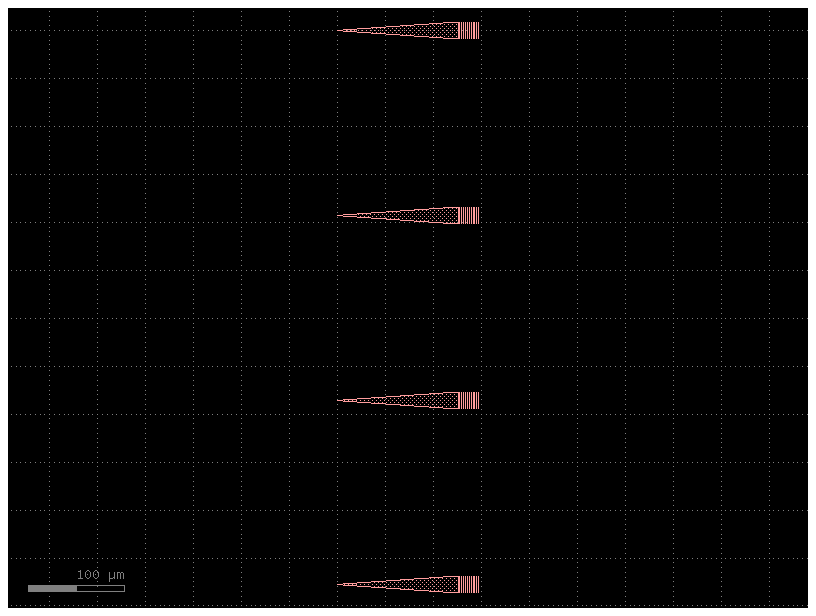

In [12]:
@gf.cell
def array_Grating(num=4) -> gf.Component:  
    c = gf.Component()
    grat = grating()

    for i in range(num):
        ref = c << grat
        ref.movey(-i * (175+17.7)) # REVISAR VALOR 127
        c.add_port(f"o{i+1}", port=ref.ports[f"i{0}"],port_type="electrical")
    
    #c.draw_ports()
    return c

wafer_fin = gf.Component()
c_fin = wafer_fin.add_ref(array_Grating())

wafer_fin.show()
wafer_fin.plot()

## Crear la estructura en el DIE

Una vez se tienen todos los componentes, se agregaron al DIE los cwdm, entre ellos tienen pequeñas variaciones de longitudes, ya sea de la longitud de los caminos o de acoplo. Esto para verificar en con cual iteración da el mejor resultado. 

Tambien se realizaron estructuras de prueba, para caracterizar los diferentes componentes que hacen parte del cwdm. De manera que se colocaron guias de onda, una de ellas con bends para caracterizar estos tambien, los bloques s1, s2 y el s2 con la compensación de longitud, estos ultimos se pusieron tambien con variación de longitud, para ver como afecta su respuesta esa variación.  

2026-05-24 11:53:38.700 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


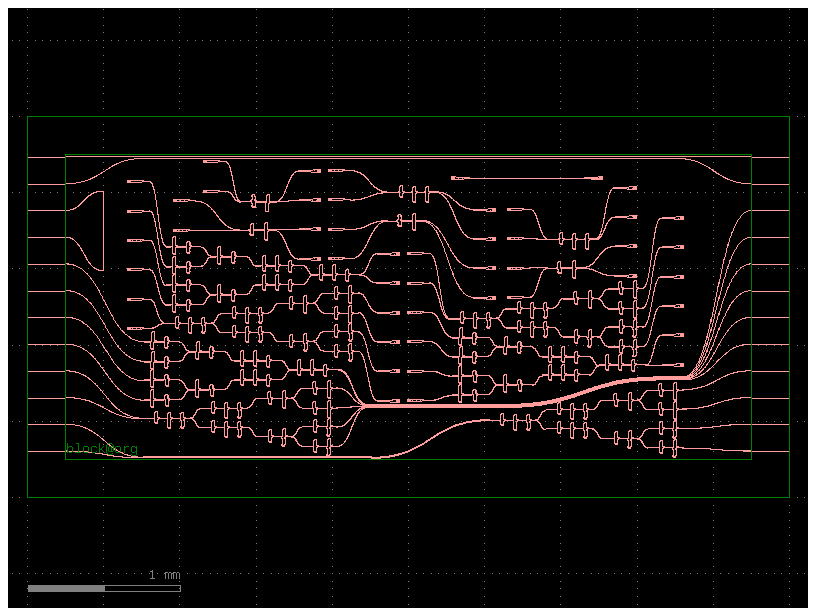

In [13]:
L_seguridad=10
sp_in_out = 175


main = gf.Component()
gratin_coup=grating()

die_ref = main.add_ref(die(dieL=2500))
cwdm = main.add_ref(CWDM())
cwdm2 = main.add_ref(CWDM(L1=L_1+0.1))
cwdm3 = main.add_ref(CWDM(L1=L_1-0.1))
cwdm4 = main.add_ref(CWDM())
cwdm5 = main.add_ref(CWDM(k=[x + 0.1 for x in Length_DC]))
cwdm6 = main.add_ref(CWDM(k=[x - 0.1 for x in Length_DC]))
cwdm7 = main.add_ref(CWDM(L1=L_1-0.1,k=[x - 0.1 for x in Length_DC]))

# Arrays de edge coupling de entrada/salida
in_arr = main.add_ref(gf.components.straight_array(n=12, spacing=sp_in_out, length=border, cross_section=xs))
out_arr = main.add_ref(gf.components.straight_array(n=12, spacing=sp_in_out, length=border, cross_section=xs))

# Arrays para interconexión dentro del circuito
in_arr_cwdm2 = main.add_ref(gf.components.straight_array(n=2, spacing=L_entre_puertosDC, length=1.5e3, cross_section=xs))
out_arr_cwdm = main.add_ref(gf.components.straight_array(n=6, spacing=L_entre_puertosDC, length=border/2, cross_section=xs))
out_arr_cwdm_2 = main.add_ref(gf.components.straight_array(n=6, spacing=L_entre_puertosDC, length=900, cross_section=xs))


# grating couplers de entrada/salida           
gc1=main.add_ref(array_Grating(num=6))
gc2=main.add_ref(array_Grating(num=6))

gc3=main.add_ref(array_Grating(num=6))
gc4=main.add_ref(array_Grating(num=6))

#Estructuras de caracterización de cada bloque

S1 = main.add_ref(s1())
S2 = main.add_ref(s2())
gc5 = main.add_ref(array_Grating())
gc6 = main.add_ref(array_Grating())

S1_1 = main.add_ref(s1())
S2_1 = main.add_ref(s2(L1=L_1-0.05))
gc5_1 = main.add_ref(array_Grating())
gc6_1 = main.add_ref(array_Grating())

S2_b=main.add_ref(s2(L1=L_1+0.5*L_pi_select))
S2_b_1=main.add_ref(s2(L1=L_1+0.5*L_pi_select+0.05))
gc7 = main.add_ref(array_Grating(num=2))
gc7_1 = main.add_ref(array_Grating(num=2))
gc8 = main.add_ref(array_Grating())

wvg_n=main.add_ref(gf.components.straight(length=3500, cross_section=xs))
wvg_g=main.add_ref(gf.components.straight(length=500, cross_section=xs))
gc_wv_i = main.add_ref(grating())
gc_wv_o = main.add_ref(grating())

wvg=main.add_ref(gf.components.straight(length=500, cross_section=xs))
bend_up=main.add_ref(gf.components.bend_euler(cross_section=xs))
bend_down=main.add_ref(gf.components.bend_euler(cross_section=xs))


#-------------------  movimiento de estructuras para los cwdm ------------------------

cwdm.dmovex(die_ref["block@org"].dx+2*L_seguridad+500).dmovey(die_ref['block@org'].dy + 4*Delta1+2*L_seguridad) # acceder a las direcciones de cada puerto
cwdm2.dmovex(cwdm["o0"].dx+L_seguridad+1000).dmovey(die_ref['block@org'].dy +4*Delta1+L_seguridad) # acceder a las direcciones de cada puerto
cwdm3.rotate(180).dmovex(cwdm["o3"].dx).dmovey(cwdm["o3"].dy+120)
cwdm4.rotate(180).dmovex(cwdm2["o3"].dx-250).dmovey(cwdm["o3"].dy+150)
cwdm5.dmovex(cwdm["i0"].dx+150).dmovey(cwdm3["o0"].dy+120)
cwdm6.dmovex(cwdm2["i0"].dx-250).dmovey(cwdm4["o0"].dy+120)
cwdm7.rotate(180).dmovex(cwdm5["o3"].dx).dmovey(cwdm5["o3"].dy+120)

# array de acoples laterales de salida y entrada
in_arr.dmovey(border + 5.5*L_seguridad)  
out_arr.dmovex(dieW - border).dmovey(border + 5.5*L_seguridad)

# array de guias para conectar salidas/entradas y llevarlas a otro punto
in_arr_cwdm2.dmovey(border + L_seguridad).dmovex(cwdm['i0'].dx)  
out_arr_cwdm.dmovey(cwdm2['o3'].dy+Delta1+DistMinAcople).dmovex(cwdm2['o3'].dx-border/2)  
out_arr_cwdm_2.dmovey(cwdm['o2'].dy).dmovex(cwdm['o3'].dx+200)  

# Grating couplings para algunos cwdm 
gc1.rotate(180).dmovex(cwdm4["o0"].dx-150).dmovey(cwdm4["o3"].dy-0.5*Delta1)
gc2.dmovex(cwdm4["i0"].dx+100).dmovey(cwdm4["i0"].dy+5*(175+17.7))

gc3.rotate(180).dmovex(cwdm5["i0"].dx-100).dmovey(cwdm5["i0"].dy-0.5*Delta1)
gc4.dmovex(cwdm5["o0"].dx+125).dmovey(gc1["o6"].dy)


#---------------------- Estructuras de caracterización de cada bloque ---------------
S1.dmovex(cwdm2["i0"].dx+400).dmovey(dieW/2-border-9*Delta1)
S1_1.dmovex(cwdm["o0"].dx+350).dmovey(dieW/2-border-4*Delta1)
S2.dmovex(S1["i0"].dx).dmovey(S1["i0"].dy-3*Delta1)
S2_1.dmovex(S1_1["i0"].dx).dmovey(S1_1["i0"].dy-3*Delta1)
S2_b.dmovex(cwdm["i0"].dx+650).dmovey(dieW/2-border-5*Delta1)
S2_b_1.dmovex(S2_b["i0"].dx).dmovey(S2_b["i0"].dy-3*Delta1+1.3)
wvg_n.dmovex(cwdm["i0"].dx).dmovey(dieW/2-border-2.5*L_seguridad)
wvg_g.dmovex(cwdm2["i0"].dx).dmovey(dieW/2-border-2.5*Delta1)
wvg.rotate(90).dmovex(500).dmovey(1500)
bend_up.connect('o1',wvg["o2"])
bend_down.connect('o2',wvg["o1"])

# movimiento de los gratings a los que iran conectados
gc5.rotate(180).dmovex(S1["i0"].dx-125).dmovey(S1["i0"].dy-6*Delta1-4.7)
gc6.dmovex(S1["o0"].dx+125).dmovey(S1["o0"].dy+5.5*Delta1)
gc5_1.rotate(180).dmovex(S1_1["i0"].dx-250).dmovey(S1_1["i0"].dy-7*Delta1)
gc6_1.dmovex(S1_1["o0"].dx+250).dmovey(gc5["o4"].dy)
gc7.rotate(180).dmovex(S2_b["i0"].dx-300).dmovey(S2_b["i0"].dy-3*Delta1)
gc7_1.rotate(180).dmovex(S2_b["i0"].dx-100).dmovey(S2_b["i0"].dy+Delta1+L_seguridad)
gc8.dmovex(S2_b["o0"].dx+150).dmovey(gc5_1["o4"].dy-2)

gc_wv_i.rotate(180).dmovex(wvg_g["o1"].dx-100).dmovey(wvg_g["o2"].dy)
gc_wv_o.dmovex(wvg_g["o2"].dx+100).dmovey(wvg_g["o2"].dy)


# enrutamiento de cada dispositivo con su respectiva salida del circuito

for i in range (0,6,1):
    gf.routing.route_single_sbend(component=main, port1=out_arr_cwdm_2[f'o{12-i}'], port2=out_arr_cwdm[f'o{1+i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=out_arr_cwdm[f'o{12-i}'], port2=out_arr[f'o{5+i}'], cross_section=xs)

for i in range(0,4,1):
    gf.routing.route_single_sbend(component=main, port1=cwdm[f'o{0+i}'], port2=out_arr_cwdm_2[f'o{1+i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=cwdm2[f'o{0+i}'], port2=out_arr[f'o{1+i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=cwdm3[f'o{0+i}'], port2=in_arr[f'o{17+i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=cwdm4[f'o{0+i}'], port2=gc1[f'o{4-i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=cwdm5[f'o{0+i}'], port2=gc4[f'o{6-i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=cwdm6[f'o{3-i}'], port2=gc2[f'o{1+i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=cwdm7[f'o{0+i}'], port2=gc3[f'o{6-i}'], cross_section=xs)
    
for i in range(0,2,1):
    gf.routing.route_single_sbend(component=main, port1=in_arr[f'o{21+i}'], port2=cwdm[f'i{1-i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=in_arr[f'o{23+i}'], port2=in_arr_cwdm2[f'o{2-i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=in_arr_cwdm2[f'o{3+i}'], port2=cwdm2[f'i{1-i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=cwdm3[f'i{0+i}'], port2=out_arr_cwdm_2[f'o{6-i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=cwdm4[f'i{0+i}'], port2=gc2[f'o{5+i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=cwdm6[f'i{1-i}'], port2=gc1[f'o{6-i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=cwdm5[f'i{0+i}'], port2=gc3[f'o{1+i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=cwdm7[f'i{0+i}'], port2=gc4[f'o{1+i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=S1[f'i{1-i}'], port2=gc5[f'o{4-i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=S2[f'i{1-i}'], port2=gc5[f'o{2-i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=S1[f'o{1-i}'], port2=gc6[f'o{1+i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=S2[f'o{1-i}'], port2=gc6[f'o{3+i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=S1_1[f'i{1-i}'], port2=gc5_1[f'o{4-i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=S2_1[f'i{1-i}'], port2=gc5_1[f'o{2-i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=S1_1[f'o{1-i}'], port2=gc6_1[f'o{1+i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=S2_1[f'o{1-i}'], port2=gc6_1[f'o{3+i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=S2_b[f'i{1-i}'], port2=gc7_1[f'o{2-i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=S2_b_1[f'i{1-i}'], port2=gc7[f'o{2-i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=S2_b[f'o{1-i}'], port2=gc8[f'o{1+i}'], cross_section=xs)
    gf.routing.route_single_sbend(component=main, port1=S2_b_1[f'o{1-i}'], port2=gc8[f'o{3+i}'], cross_section=xs)



gf.routing.route_single_sbend(component=main, port1=gc_wv_i['i0'], port2=wvg_g['o1'], cross_section=xs)
gf.routing.route_single_sbend(component=main, port1=wvg_g['o2'], port2=gc_wv_o['o0'], cross_section=xs)
gf.routing.route_single_sbend(component=main, port1=in_arr['o15'], port2=bend_up['o2'], cross_section=xs)
gf.routing.route_single_sbend(component=main, port1=in_arr['o16'], port2=bend_down['o1'], cross_section=xs)
gf.routing.route_single_sbend(component=main, port1=in_arr['o13'], port2=out_arr['o12'], cross_section=xs)
gf.routing.route_single_sbend(component=main, port1=in_arr['o14'], port2=wvg_n['o1'], cross_section=xs)
gf.routing.route_single_sbend(component=main, port1=wvg_n['o2'], port2=out_arr['o11'], cross_section=xs)


main.draw_ports()
main.plot()
main.show()


Por útlimo se le agregaron nombres a los puertos de entrada/salida de los cwdm

2026-05-24 11:53:43.780 | WARNING  | kfactory.kcell:show:3958 - Could not connect to klive server


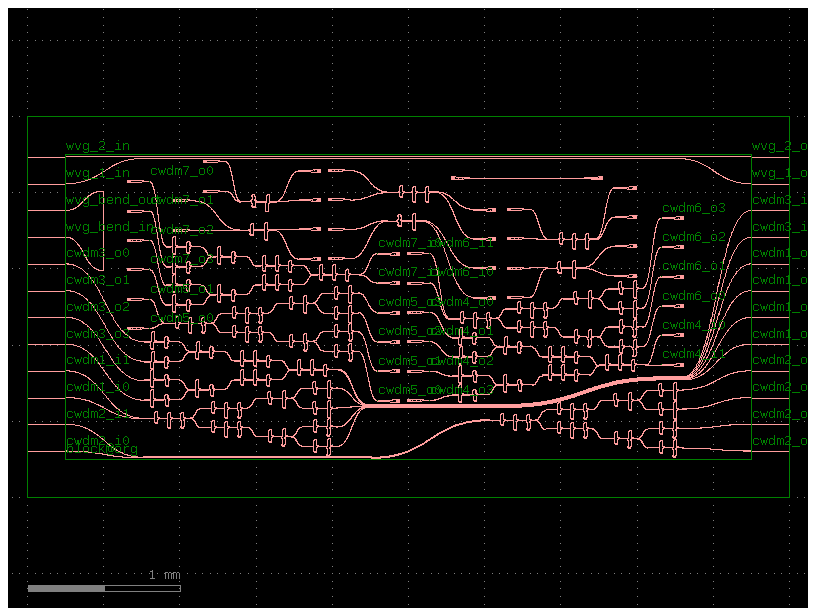

In [14]:
# Nombres de los puertos de salida 

main.add_port(name="cwdm2_i0", center=[in_arr['o24'].dx,in_arr['o24'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm2_i1", center=[in_arr['o23'].dx,in_arr['o23'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm1_i0", center=[in_arr['o22'].dx,in_arr['o22'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm1_i1", center=[in_arr['o21'].dx,in_arr['o21'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm3_o3", center=[in_arr['o20'].dx,in_arr['o20'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm3_o2", center=[in_arr['o19'].dx,in_arr['o19'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm3_o1", center=[in_arr['o18'].dx,in_arr['o18'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm3_o0", center=[in_arr['o17'].dx,in_arr['o17'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="wvg_bend_in", center=[in_arr['o16'].dx,in_arr['o16'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="wvg_bend_out", center=[in_arr['o15'].dx,in_arr['o15'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="wvg_1_in", center=[in_arr['o14'].dx,in_arr['o14'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="wvg_2_in", center=[in_arr['o13'].dx,in_arr['o13'].dy], width=width, orientation=180, layer=layer_box)

main.add_port(name="cwdm2_o0", center=[out_arr['o1'].dx,out_arr['o1'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm2_o1", center=[out_arr['o2'].dx,out_arr['o2'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm2_o2", center=[out_arr['o3'].dx,out_arr['o3'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm2_o3", center=[out_arr['o4'].dx,out_arr['o4'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm1_o0", center=[out_arr['o5'].dx,out_arr['o5'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm1_o1", center=[out_arr['o6'].dx,out_arr['o6'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm1_o2", center=[out_arr['o7'].dx,out_arr['o7'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm1_o3", center=[out_arr['o8'].dx,out_arr['o8'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm3_i1", center=[out_arr['o9'].dx,out_arr['o9'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm3_i0", center=[out_arr['o10'].dx,out_arr['o10'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="wvg_1_out", center=[out_arr['o11'].dx,out_arr['o11'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="wvg_2_out", center=[out_arr['o12'].dx,out_arr['o12'].dy], width=width, orientation=180, layer=layer_box)


main.add_port(name="cwdm4_o3", center=[gc1['o1'].dx,gc1['o1'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm4_o2", center=[gc1['o2'].dx,gc1['o2'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm4_o1", center=[gc1['o3'].dx,gc1['o3'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm4_o0", center=[gc1['o4'].dx,gc1['o4'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm6_i0", center=[gc1['o5'].dx,gc1['o5'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm6_i1", center=[gc1['o6'].dx,gc1['o6'].dy], width=width, orientation=180, layer=layer_box)

main.add_port(name="cwdm6_o3", center=[gc2['o1'].dx,gc2['o1'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm6_o2", center=[gc2['o2'].dx,gc2['o2'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm6_o1", center=[gc2['o3'].dx,gc2['o3'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm6_o0", center=[gc2['o4'].dx,gc2['o4'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm4_i0", center=[gc2['o5'].dx,gc2['o5'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm4_i1", center=[gc2['o6'].dx,gc2['o6'].dy], width=width, orientation=180, layer=layer_box)

main.add_port(name="cwdm5_o0", center=[gc3['o1'].dx,gc3['o1'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm5_o1", center=[gc3['o2'].dx,gc3['o2'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm7_o3", center=[gc3['o3'].dx,gc3['o3'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm7_o2", center=[gc3['o4'].dx,gc3['o4'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm7_o1", center=[gc3['o5'].dx,gc3['o5'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm7_o0", center=[gc3['o6'].dx,gc3['o6'].dy], width=width, orientation=180, layer=layer_box)

main.add_port(name="cwdm7_i0", center=[gc4['o1'].dx,gc4['o1'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm7_i1", center=[gc4['o2'].dx,gc4['o2'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm5_o3", center=[gc4['o3'].dx,gc4['o3'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm5_o2", center=[gc4['o4'].dx,gc4['o4'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm5_o1", center=[gc4['o5'].dx,gc4['o5'].dy], width=width, orientation=180, layer=layer_box)
main.add_port(name="cwdm5_o0", center=[gc4['o6'].dx,gc4['o6'].dy], width=width, orientation=180, layer=layer_box)


main.draw_ports()
main.plot()
main.show()